# 1. Import thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.cluster import AgglomerativeClustering

# 2. DATA


In [34]:
data = load_iris()
X = data.data
y_true = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


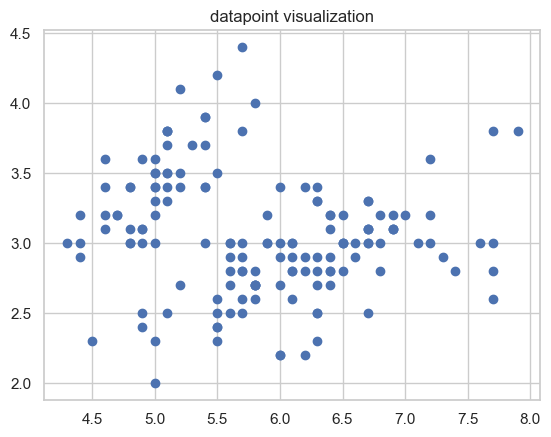

In [35]:
plt.scatter(X[:, 0], X[:, 1])
plt.title("datapoint visualization")
plt.show()

# 3. Huấn luyện mô hình

In [ ]:
model = AgglomerativeClustering(n_clusters=3, linkage='complete')

cluster_labels = model.fit_predict(X_scaled)

print(f"Silhouette Score: {silhouette_score(X_scaled, cluster_labels):.4f}")
print(f"Davies-Bouldin Score: {davies_bouldin_score(X_scaled, cluster_labels):.4f}")

Silhouette Score: 0.4496
Davies-Bouldin Score: 0.7584


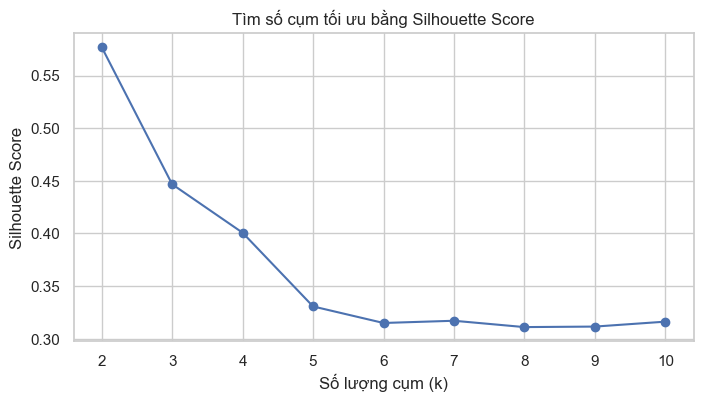

In [59]:
from sklearn.metrics import silhouette_score

K = range(2, 11)
sil_scores = []

for k in K:
    m = AgglomerativeClustering(n_clusters=k)
    lab = m.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, lab))

plt.figure(figsize=(8, 4))
plt.plot(K, sil_scores, 'bo-')
plt.title("Tìm số cụm tối ưu bằng Silhouette Score")
plt.xlabel("Số lượng cụm (k)")
plt.ylabel("Silhouette Score")
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# số cụm tốt nhất
for k in range(2, 11):
    m = AgglomerativeClustering(n_clusters=k)
    l = m.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, l)
    print(f"Số cụm k={k}: Silhouette Score = {score:.4f}")

Số cụm k=2: Silhouette Score = 0.5770
Số cụm k=3: Silhouette Score = 0.4467
Số cụm k=4: Silhouette Score = 0.4006
Số cụm k=5: Silhouette Score = 0.3306
Số cụm k=6: Silhouette Score = 0.3149
Số cụm k=7: Silhouette Score = 0.3170
Số cụm k=8: Silhouette Score = 0.3109
Số cụm k=9: Silhouette Score = 0.3114
Số cụm k=10: Silhouette Score = 0.3161


# 4. Đánh giá

In [69]:
si_score = silhouette_score(X_scaled, cluster_labels)
db_score = davies_bouldin_score(X_scaled, cluster_labels)
ch_score = calinski_harabasz_score(X_scaled, cluster_labels)

print(f"Silhouette Score: {si_score:.4f}")
print(f"Davies-Bouldin Score: {db_score:.4f}")
print(f"Calinski-Harabasz Score: {ch_score:.4f}")

Silhouette Score: 0.4496
Davies-Bouldin Score: 0.7584
Calinski-Harabasz Score: 213.0817


# 5. Trực quan hóa kết quả


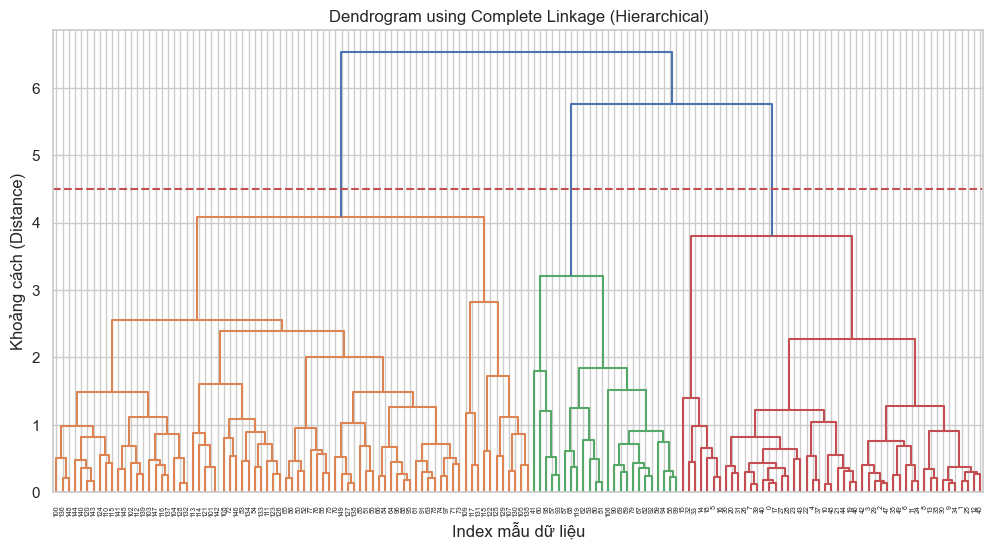

In [67]:
# 5.1 Dendrogram
Z = linkage(X_scaled, method='complete')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.axhline(y=4.5, color='r', linestyle='--') 
plt.title("Dendrogram using Complete Linkage (Hierarchical)")
plt.xlabel("Index mẫu dữ liệu")
plt.ylabel("Khoảng cách (Distance)")
plt.show()

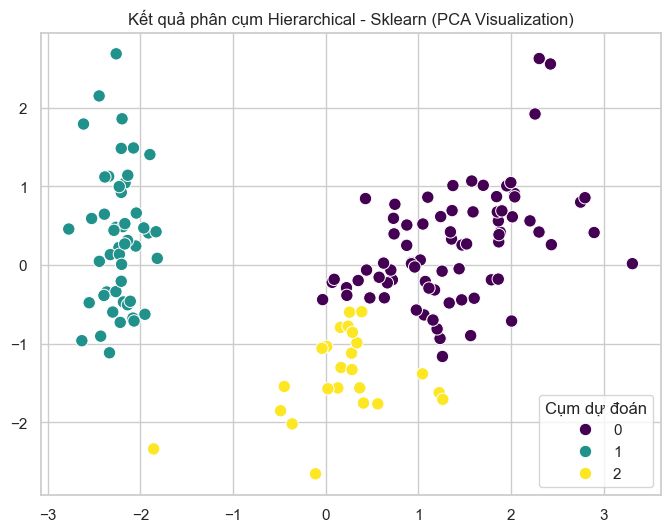

In [66]:
# 5.2 Trực quan hóa với PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=cluster_labels, palette='viridis', s=80, edgecolor='w')
plt.title("Kết quả phân cụm Hierarchical - Sklearn (PCA Visualization)")
plt.legend(title='Cụm dự đoán')
plt.show()

# Chọn số phân cụm là 3


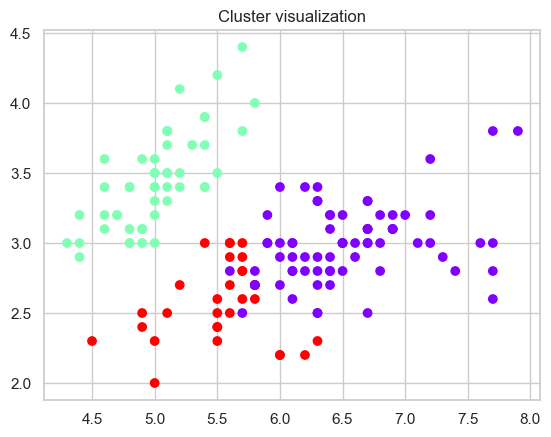

In [52]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
plt.title("Cluster visualization")
plt.show()

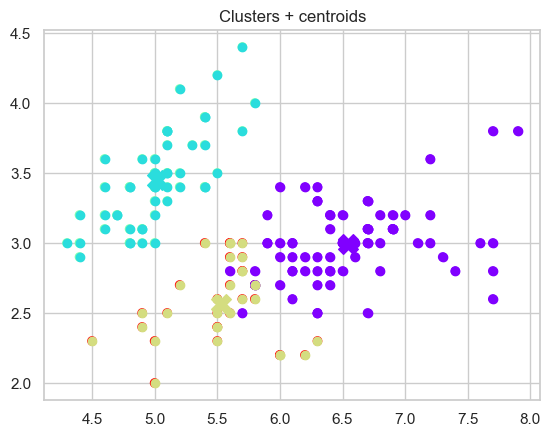

In [53]:
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow')
for c in np.unique(labels):
    points = X[labels == c]
    centroid = points.mean(axis=0)
    
    color = plt.cm.rainbow(c / len(np.unique(labels)))
    
    plt.scatter(points[:, 0], points[:, 1], color=color)
    plt.scatter(centroid[0], centroid[1], s=200, marker='X', color=color)

plt.title("Clusters + centroids")
plt.show()

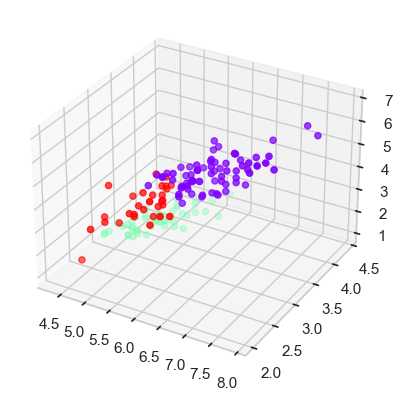

In [47]:

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='rainbow')

plt.show()


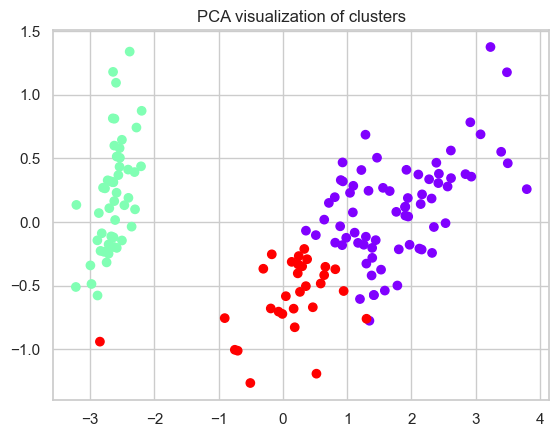

In [46]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='rainbow')
plt.title("PCA visualization of clusters")
plt.show()